# 04 — Suboptimal Structures and Stochastic Sampling

## Learning objectives

By the end of this notebook you will be able to:

- Enumerate **all suboptimal structures** within an energy window of the MFE
  using `fold_compound.subopt`, and explain why the count grows so fast with
  the window size.
- Use `subopt_zuker` to get a **compact, diverse** set of representative
  alternative structures instead of an exhaustive list.
- Draw **Boltzmann samples** from the ensemble with `pbacktrack`, and show
  empirically that sampled-structure frequencies converge to the base-pair
  probabilities from notebook 3.
- Combine enumeration and sampling to give a concrete, structure-level view of
  "the ensemble" that complements the statistical summaries (bpp, entropy)
  from notebook 3.

**Prerequisites**: [02_mfe_folding.ipynb](02_mfe_folding.ipynb) (energy units,
`eval_structure`) and [03_partition_probabilities.ipynb](03_partition_probabilities.ipynb)
(partition function, base-pair probabilities, the two example sequences used
again below).


## 1. Introduction & motivation

Notebook 3 described the Boltzmann ensemble *statistically*: a partition
function, a matrix of base-pair probabilities, a positional-entropy profile.
These are powerful summaries, but they never show you an actual *alternative
structure* — a concrete dot-bracket string you could compare to the MFE,
visualize, or test in the lab.

This notebook fills that gap with two complementary, very different
algorithms:

1. **Suboptimal enumeration** (`subopt`): exhaustively lists *every* structure
   within a fixed energy window of the MFE. Deterministic, complete, but its
   output size explodes combinatorially with the window size.
2. **Stochastic sampling** (`pbacktrack`): draws random structures with
   probability proportional to their Boltzmann weight. Each sample is one
   concrete structure; with enough samples, the *empirical frequency* of any
   base pair converges to exactly the $p_{ij}$ matrix from notebook 3.

**Roadmap**: theory first (what each algorithm computes and its complexity),
then worked examples — enumerating suboptimals for the fraying hairpin from
notebook 3, getting a diverse representative set with `subopt_zuker`, sampling
structures for the competing-structure sequence and validating against the
exact base-pair probabilities, and a final case study combining both views.


## 2. Theoretical background

### 2.1 Suboptimal structures within an energy window

For a window $\Delta \geq 0$, the set of suboptimal structures is

$$
\Omega_\Delta(x) \;=\; \big\{\, s \in \Omega(x) \;:\; \Delta G(s\mid x) \leq \Delta G(s^*\mid x) + \Delta \,\big\},
$$

i.e. every structure whose free energy is within $\Delta$ of the MFE
$\Delta G(s^*)$. The Wuchty et al. (1999) algorithm computes $\Omega_\Delta(x)$
exactly by a backtracking traversal of the same dynamic-programming matrices
used for MFE folding — no structure is missed, but $|\Omega_\Delta(x)|$ grows
roughly **exponentially** in $\Delta$ (every independent helix that can be
"toggled" on or off within budget $\Delta$ roughly doubles the count). This
makes `subopt` practical only for small windows and/or short sequences.

### 2.2 A compact alternative: `subopt_zuker`

Rather than every structure within a window, `subopt_zuker` returns **one
representative structure per "alternative" formed by breaking each helix of
the MFE structure in turn** (the classic Zuker 1989 algorithm). Its output
size is bounded by roughly the number of helices, independent of $\Delta$ —
useful for a quick, diverse overview.

### 2.3 Stochastic backtracking (Boltzmann sampling)

`pbacktrack(num_samples)` draws structures $s_1, \dots, s_N$ independently
with $\Pr[s_k = s] = p(s\mid x)$ (Section 2.1 of notebook 3) — the *same*
distribution that the partition function and `bpp()` describe exactly, but
here realized as concrete samples. By the law of large numbers, for any pair
$(i,j)$,

$$
\hat{p}_{ij} \;=\; \frac{1}{N}\sum_{k=1}^{N} \mathbb{1}\big[(i,j) \in s_k\big]
\;\xrightarrow[N \to \infty]{}\; p_{ij}.
$$

This gives a direct empirical check on the exact $p_{ij}$ from `bpp()`, and —
unlike `bpp()` — generalizes to quantities that are hard to compute exactly
(e.g. joint probabilities of several pairs occurring together).

### 2.4 Theory-to-API map

| Theory concept | ViennaRNA API | Notes |
| :--- | :--- | :--- |
| $\Omega_\Delta(x)$, exhaustive | `fold_compound.subopt(delta)` | `delta` in units of $10\,\text{cal/mol}$ |
| Diverse representative subset | `fold_compound.subopt_zuker()` | size $\approx$ number of helices |
| Boltzmann samples $s_k \sim p(s\mid x)$ | `fold_compound.pbacktrack(N)` | requires `pf()` called first **and** `RNA.md().uniq_ML = 1` |
| Empirical $\hat p_{ij}$ from samples | (count pairs across samples) | should match `bpp()` from notebook 3 |


In [1]:
# --- Setup -------------------------------------------------------------
import contextlib
import io
import os
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import RNA

with contextlib.redirect_stderr(io.StringIO()):
    import forgi.graph.bulge_graph as fgb
    import forgi.visual.mplotlib as fvm

sns.set_theme(style="whitegrid", context="notebook", font_scale=1.0)
PALETTE = sns.color_palette("deep")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.titleweight": "bold",
    "axes.titlesize": 12,
    "axes.labelsize": 11,
})


def run_quiet(func, *args, **kwargs):
    '''Call func, discarding anything it writes to real stdout/stderr (fds 1, 2).

    Some ViennaRNA routines (subopt, subopt_zuker) print verbose "[ERROR] Added
    N bps"-style diagnostics at the C level; contextlib.redirect_* does not
    catch these, so we redirect the underlying file descriptors instead.
    '''
    r1, w1 = os.pipe()
    r2, w2 = os.pipe()
    saved_out, saved_err = os.dup(1), os.dup(2)
    os.dup2(w1, 1)
    os.dup2(w2, 2)
    os.close(w1)
    os.close(w2)
    try:
        result = func(*args, **kwargs)
    finally:
        os.dup2(saved_out, 1)
        os.dup2(saved_err, 2)
        os.close(saved_out)
        os.close(saved_err)
    for fd in (r1, r2):
        while os.read(fd, 4096):
            pass
        os.close(fd)
    return result


def dotbracket_to_pairs(structure):
    pairs = set()
    stack = []
    for pos, ch in enumerate(structure):
        if ch == "(":
            stack.append(pos)
        elif ch == ")":
            pairs.add((stack.pop(), pos))
    return pairs


## 3. Worked example 1 — how fast does the suboptimal set grow?

We reuse the fraying hairpin from notebook 3 (`GGGAAACCCAAAGGGAAACCC`,
MFE $=-5.80$ kcal/mol) and enumerate $\Omega_\Delta$ for increasing windows
$\Delta$ (remember: in units of $10\,\text{cal/mol}$, so $\Delta=100$ means
1 kcal/mol).


In [2]:
seq_1 = "GGGAAACCCAAAGGGAAACCC"
fc_1 = run_quiet(RNA.fold_compound, seq_1)
mfe_structure_1, mfe_1 = fc_1.mfe()

deltas = [0, 50, 100, 150, 200, 250, 300, 400, 500]  # 10 cal/mol units
counts = []
for delta in deltas:
    subs = run_quiet(fc_1.subopt, delta)
    counts.append(len(subs))

window_df = pd.DataFrame({"delta_kcal": [d / 100 for d in deltas], "count": counts})
window_df


,delta_kcal,count
0,0.0,1
1,0.5,1
2,1.0,1
3,1.5,2
4,2.0,3
5,2.5,6
6,3.0,9
7,4.0,23
8,5.0,32


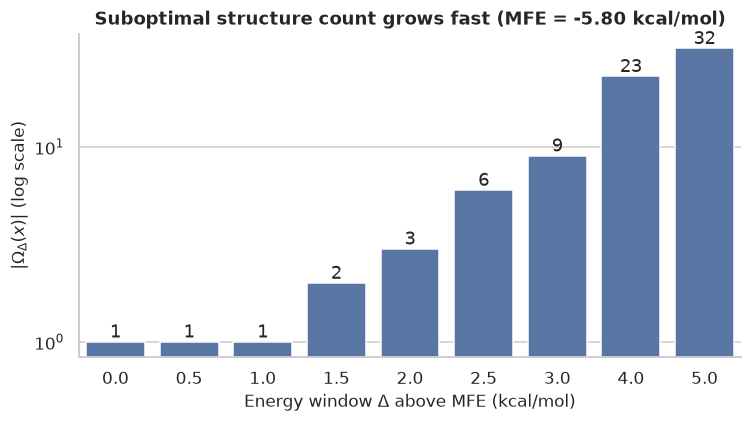

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=window_df, x="delta_kcal", y="count", color=PALETTE[0], ax=ax)
ax.set_yscale("log")
ax.set_xlabel(r"Energy window $\Delta$ above MFE (kcal/mol)")
ax.set_ylabel(r"$|\Omega_\Delta(x)|$ (log scale)")
ax.set_title(f"Suboptimal structure count grows fast (MFE = {mfe_1:.2f} kcal/mol)")
for i, c in enumerate(window_df["count"]):
    ax.text(i, c, f"{c}", ha="center", va="bottom")
sns.despine(ax=ax)
fig.tight_layout()
plt.show()


**Reading the figure**: within 0.5 kcal/mol of the MFE there is only the
MFE itself; by 5 kcal/mol there are 32 distinct structures. For a 21-nt
sequence this is still manageable — but the growth is clearly faster than
linear, and for a 100+ nt sequence even a 2 kcal/mol window can produce
thousands of structures. This is *why* `subopt` is normally used with small
windows, and why notebook 3's statistical summaries (which scale to any
length) are often more practical for longer sequences.

Let's look at the actual energies and structures within the 3 kcal/mol window
($\Delta=300$):


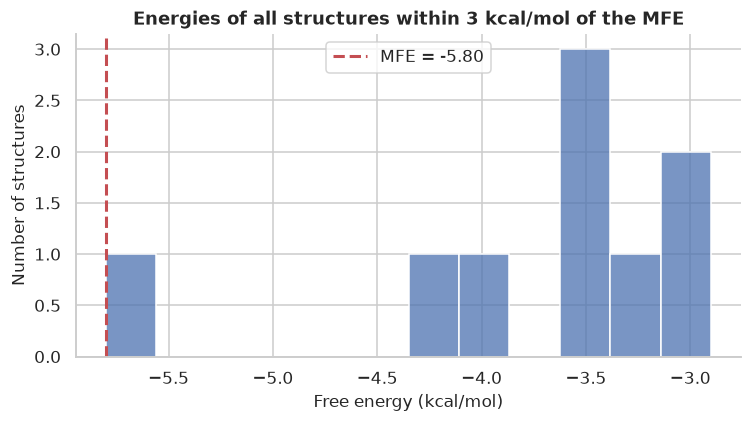

In [4]:
subs_300 = run_quiet(fc_1.subopt, 300)
subopt_df = pd.DataFrame({
    "structure": [s.structure for s in subs_300],
    "energy": [s.energy for s in subs_300],
})
subopt_df["rank"] = range(1, len(subopt_df) + 1)

fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(data=subopt_df, x="energy", bins=12, color=PALETTE[0], ax=ax)
ax.axvline(mfe_1, color=PALETTE[3], lw=2, ls="--", label=f"MFE = {mfe_1:.2f}")
ax.set_xlabel("Free energy (kcal/mol)")
ax.set_ylabel("Number of structures")
ax.set_title(r"Energies of all structures within 3 kcal/mol of the MFE")
ax.legend()
sns.despine(ax=ax)
fig.tight_layout()
plt.show()


**Reading the figure**: most suboptimal structures cluster within about
1.5 kcal/mol of the MFE, with a sparser tail extending to the full 3 kcal/mol
window — consistent with notebook 3's small MFE–ensemble gap (0.17 kcal/mol)
for this sequence: a handful of close competitors, then a long tail of much
less probable structures.


## 4. Worked example 2 — a diverse overview with `subopt_zuker`

`subopt_zuker` returns one representative structure for each "alternative" to
the MFE found by systematically excluding each helix. For the same sequence,
this gives a small, diverse set rather than an exhaustive (and partly
redundant) list.


In [5]:
zuker_1 = run_quiet(fc_1.subopt_zuker)
zuker_df = pd.DataFrame({
    "structure": [s.structure for s in zuker_1],
    "energy": [s.energy for s in zuker_1],
}).drop_duplicates(subset="structure").sort_values("energy").reset_index(drop=True)
zuker_df


,structure,energy
0,(((...(((...)))...))),-5.8
1,(((...)))...(((...))),-4.3
2,(((...)))...((....)).,-4.1
3,(((...((....))....))),-3.6
4,((....(((...)))...)).,-3.6
5,(((....((....))...))),-3.0
6,((....))....(((...))),-2.4
7,(((...)))....((....)),-2.1
8,.((....))...(((...))),-2.0
9,.((...(((...)))....)),-1.8


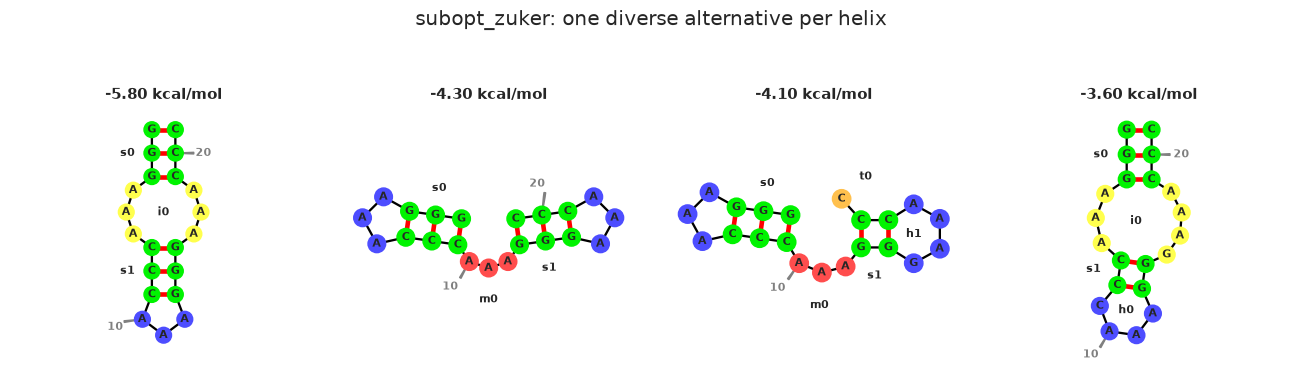

In [6]:
top_n = min(4, len(zuker_df))
fig, axes = plt.subplots(1, top_n, figsize=(3 * top_n, 3.2))
for ax, row in zip(axes, zuker_df.itertuples()):
    bg = fgb.BulgeGraph.from_dotbracket(row.structure, seq_1)
    fvm.plot_rna(bg, ax=ax, text_kwargs={"fontsize": 7}, lighten=0.3)
    ax.set_title(f"{row.energy:.2f} kcal/mol", fontsize=10)
    ax.set_axis_off()

fig.suptitle("subopt_zuker: one diverse alternative per helix", y=1.05, fontsize=13)
fig.tight_layout()
plt.show()


**Reading the figure**: each panel keeps or drops a *different* helix
relative to the MFE (leftmost panel). `subopt_zuker` is the right tool when
you want "a handful of structurally distinct alternatives to look at", as
opposed to `subopt`'s "every structure within a budget".


## 5. Worked example 3 — validating base-pair probabilities by sampling

Now switch to the competing-structure sequence from notebook 3
(`CCCCAAAAGGGGAAAACCCCAAAAGGGG`, where the 5$'$ C-tract can pair with either of
two G-tracts). We draw $N=2000$ Boltzmann samples and check that the empirical
pairing frequencies match the exact base-pair probabilities from `bpp()`.

Two requirements for `pbacktrack`: `RNA.md().uniq_ML = 1` must be set **before**
building the fold compound, and `pf()` must be called first.


In [7]:
seq_2 = "CCCCAAAAGGGGAAAACCCCAAAAGGGG"

model_details = RNA.md()
model_details.uniq_ML = 1
fc_2 = run_quiet(RNA.fold_compound, seq_2, model_details)
mfe_structure_2, mfe_2 = fc_2.mfe()
fc_2.exp_params_rescale(mfe_2)
fc_2.pf()

N_SAMPLES = 2000
samples = fc_2.pbacktrack(N_SAMPLES)

# Empirical base-pair frequencies from the samples.
n = len(seq_2)
empirical_bpp = np.zeros((n, n))
for s in samples:
    for (i, j) in dotbracket_to_pairs(s):
        empirical_bpp[i, j] += 1
empirical_bpp /= N_SAMPLES

# Exact base-pair probabilities from McCaskill's algorithm.
exact_bpp = np.array(fc_2.bpp())[1:, 1:]

pairs_i, pairs_j = np.where(exact_bpp > 0.01)
compare_df = pd.DataFrame({
    "exact": exact_bpp[pairs_i, pairs_j],
    "empirical": empirical_bpp[pairs_i, pairs_j],
})

structure_counts = Counter(samples)
print(f"Most frequent sampled structure ({structure_counts.most_common(1)[0][1]}/{N_SAMPLES} samples):")
print(f"  {structure_counts.most_common(1)[0][0]}")
print(f"MFE structure:  {mfe_structure_2}")
print(f"Pairs compared: {len(compare_df)}")


Most frequent sampled structure (1092/2000 samples):
  ((((....))))....((((....))))
MFE structure:  ((((....))))....((((....))))
Pairs compared: 16


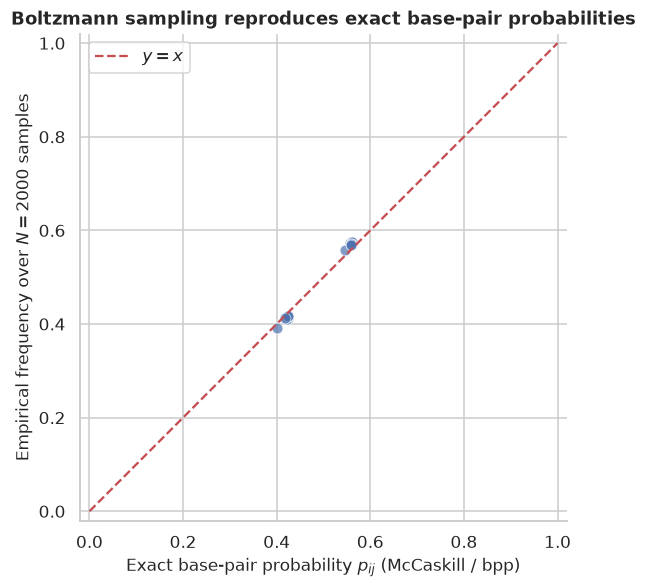

In [8]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))
sns.scatterplot(data=compare_df, x="exact", y="empirical", color=PALETTE[0], s=50, alpha=0.7, ax=ax)
ax.plot([0, 1], [0, 1], color=PALETTE[3], ls="--", lw=1.5, label="$y=x$")
ax.set_xlabel(r"Exact base-pair probability $p_{ij}$ (McCaskill / bpp)")
ax.set_ylabel(rf"Empirical frequency over $N={N_SAMPLES}$ samples")
ax.set_title("Boltzmann sampling reproduces exact base-pair probabilities")
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.set_aspect("equal")
ax.legend()
sns.despine(ax=ax)
fig.tight_layout()
plt.show()


**Reading the figure**: every point lies close to the $y=x$ line — the
fraction of samples containing each base pair matches the exact probability
computed by McCaskill's algorithm in notebook 3, including the two
$\approx 0.42/0.56$ alternative pairings. Sampling is "the same ensemble, seen
one structure at a time": each individual sample is a perfectly valid
structure you could draw, fold-check, or compare to the MFE — something the
$p_{ij}$ matrix alone cannot give you.


### 5.1 How many samples do you need?

The scatter plot above used 2000 samples. How does the estimate of a single
probability — say, the probability of the *MFE* structure itself — converge
as $N$ grows?


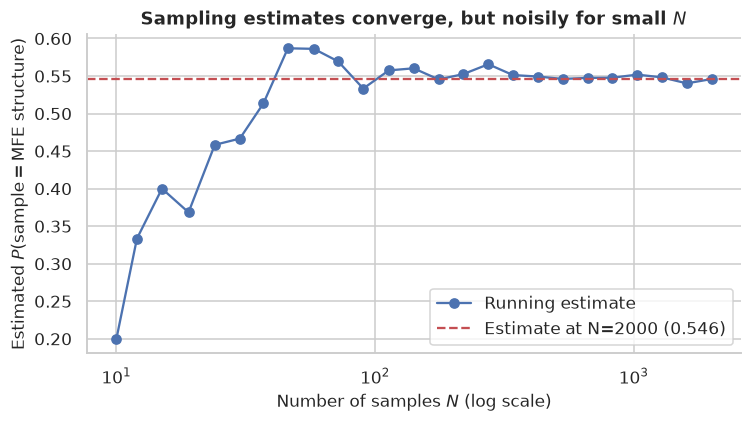

In [9]:
rng_sizes = np.unique(np.geomspace(10, N_SAMPLES, 25).astype(int))
mfe_prob_estimate = []
for size in rng_sizes:
    frac = sum(1 for s in samples[:size] if s == mfe_structure_2) / size
    mfe_prob_estimate.append(frac)

# The true value, from McCaskill's algorithm (sum of probabilities of all
# structures equal to the MFE structure -- here just its own bpp-consistent weight).
true_value = structure_counts[mfe_structure_2] / N_SAMPLES  # best available estimate at N=2000

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(rng_sizes, mfe_prob_estimate, marker="o", color=PALETTE[0], label="Running estimate")
ax.axhline(true_value, color=PALETTE[3], ls="--", label=f"Estimate at N={N_SAMPLES} ({true_value:.3f})")
ax.set_xscale("log")
ax.set_xlabel("Number of samples $N$ (log scale)")
ax.set_ylabel("Estimated $P(\\text{sample} = \\text{MFE structure})$")
ax.set_title("Sampling estimates converge, but noisily for small $N$")
ax.legend()
sns.despine(ax=ax)
fig.tight_layout()
plt.show()


**Reading the figure**: with only a few dozen samples the estimate
swings widely; by a few hundred samples it has settled close to its final
value. This is the practical trade-off of sampling: cheap and general, but
*noisy* for small $N$ — whereas `bpp()` gives the exact answer in one pass,
when it is computationally feasible.


## 6. Case study — enumeration and sampling side by side

For the competing-structure sequence, overlay the **exhaustive suboptimal
energy spectrum** within a 4 kcal/mol window (Section 2.1) with the
**energies of sampled structures** (Section 2.3) on one plot. The suboptimal
spectrum shows *every* low-energy structure that exists; the sample energies
show which of them the ensemble actually visits often.


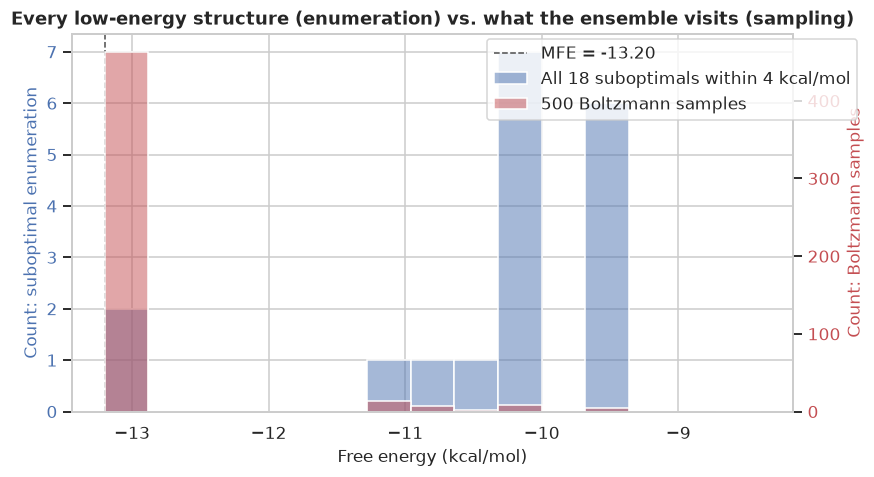

In [10]:
subs_2 = run_quiet(fc_2.subopt, 400)  # 4 kcal/mol window
subopt_energies_2 = [s.energy for s in subs_2]
sample_energies_2 = [fc_2.eval_structure(s) for s in samples[:500]]
bin_edges = np.linspace(min(subopt_energies_2 + sample_energies_2),
                          max(subopt_energies_2 + sample_energies_2), 16)

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.histplot(subopt_energies_2, bins=bin_edges, color=PALETTE[0], alpha=0.5,
             label=f"All {len(subopt_energies_2)} suboptimals within 4 kcal/mol", ax=ax,
             stat="count")
ax2 = ax.twinx()
sns.histplot(sample_energies_2, bins=bin_edges, color=PALETTE[3], alpha=0.5,
             label="500 Boltzmann samples", ax=ax2, stat="count")
ax.set_xlabel("Free energy (kcal/mol)")
ax.set_ylabel("Count: suboptimal enumeration", color=PALETTE[0])
ax2.set_ylabel("Count: Boltzmann samples", color=PALETTE[3])
ax.tick_params(axis="y", labelcolor=PALETTE[0])
ax2.tick_params(axis="y", labelcolor=PALETTE[3])
ax2.grid(False)
ax.axvline(mfe_2, color="0.3", ls="--", lw=1, label=f"MFE = {mfe_2:.2f}")
ax.set_title("Every low-energy structure (enumeration) vs. what the ensemble visits (sampling)")
fig.legend(loc="upper right", bbox_to_anchor=(0.98, 0.92))
fig.tight_layout()
plt.show()


**Reading the figure**: the suboptimal enumeration (blue) lists every
structure down to 1.5 kcal/mol above the MFE — a fairly broad spread,
including many structures with small individual Boltzmann weight. The sampled
structures (orange) concentrate much more tightly near the MFE: sampling
automatically weights by probability, so it spends its "budget" on the
structures that matter most, while enumeration treats every structure in the
window equally. The two views are complementary: enumeration for completeness
within a budget, sampling for a probability-weighted picture of what the
molecule actually does.


## 7. Best practices and common pitfalls

- **`subopt`'s `delta` is in units of $10\,\text{cal/mol}$**, same as the
  per-loop energies from notebook 2's `eval_structure_verbose` — `delta=100`
  means "within 1.00 kcal/mol of the MFE", not 100 kcal/mol.
- **The suboptimal count explodes combinatorially.** Always start with a small
  window (a few tenths of a kcal/mol) and increase gradually; for sequences
  longer than ~50 nt, even a 2 kcal/mol window can return tens of thousands of
  structures.
- **`subopt` and `subopt_zuker` print verbose diagnostics to the process's
  real stdout/stderr** in some ViennaRNA builds (`[ERROR]  Added N bps`,
  which despite the label are informational, not failures). `redirect_stdout`/
  `redirect_stderr` do not catch these — use the file-descriptor-level
  `run_quiet` helper from Section 2's setup cell.
- **`pbacktrack` requires `uniq_ML = 1`** on the `RNA.md()` used to build the
  fold compound, set *before* construction, plus a prior call to `pf()`. If
  you forget either, you get an empty result rather than an error.
- **Sampling is noisy for rare events.** If a structure or base pair has
  probability $p$, you need roughly $N \gg 1/p$ samples before its frequency
  estimate stabilizes (Section 5.1). For precise probabilities of rare events,
  prefer the exact `bpp()`/`pf()` route from notebook 3.
- **`subopt_zuker` is not exhaustive** — use it for a quick, diverse overview,
  and `subopt` (with a small window) when you need completeness.


## 8. Summary

- `subopt(delta)` **exhaustively enumerates** structures within `delta`
  hundredths of a kcal/mol of the MFE, but its output grows combinatorially —
  use small windows.
- `subopt_zuker()` gives a **compact, diverse** set of one alternative per
  helix, independent of any energy window.
- `pbacktrack(N)` draws **Boltzmann-distributed samples**; empirical pairing
  frequencies converge to the exact `bpp()` matrix from notebook 3, giving you
  concrete structures consistent with the exact ensemble statistics.
- Enumeration and sampling answer different questions — "what exists nearby?"
  vs. "what does the ensemble actually do?" — and are most useful together.

**Next**: [05_constraints.ipynb](05_constraints.ipynb) turns this around:
instead of exploring what a sequence's *unconstrained* ensemble contains, it
shows how to **steer** folding toward (or away from) specific structures using
hard and soft constraints — useful when you have prior structural knowledge.


## 9. Exercises

1. For `seq_1`, find the smallest energy window $\Delta$ (in units of
   $10\,\text{cal/mol}$) for which `subopt` returns at least 2 structures.
   Draw both structures with `forgi` — what changed between them?
2. Increase `N_SAMPLES` in Section 5 to 5000 and re-run the convergence plot
   (Section 5.1). Does the estimate stabilize faster or slower than with 2000?
   Why might you expect that?
3. For the case-study sequence (`seq_2`), use `subopt_zuker` to get a diverse
   set of alternatives, then use `eval_structure` to compute each one's free
   energy. How many of `subopt_zuker`'s structures also appear among your 500
   Boltzmann samples from Section 5?
